<a href="https://www.kaggle.com/code/pavankumar960/global-petrol-prices-analysis-april-2026?scriptVersionId=309721026" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Project Overview

In [1]:
# Basic Libs
import numpy as np
import pandas as pd 

# Visual Libs
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "iframe"

# Data Loading

In [2]:
df = pd.read_excel("/kaggle/input/datasets/fatimafarzand/global-petrol-prices-april-2026/Petrol prices.xlsx")

# Data Overview

In [3]:
df.head()

,Country,Region,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent,Price_Trend,Price_Level
0,Hong Kong,Asia,4.11,15.56,3.78,8.7,Stable,Very High
1,Singapore,Asia,3.38,12.79,2.84,19.0,Rising Sharply,Very High
2,Netherlands,Europe,2.80,10.60,2.56,9.4,Stable,Very High
3,Denmark,Europe,2.54,9.61,2.26,12.4,Rising,Very High
4,Germany,Europe,2.47,9.35,2.18,13.3,Rising,Very High


In [4]:
df.describe()

,Price_Per_Liter_USD,Price_Per_Gallon_USD,Previous_Price_USD,Price_Change_Percent
count,101.000000,101.000000,101.000000,101.000000
mean,1.380891,5.227030,1.278911,8.030693
std,0.709434,2.685499,0.645317,14.363076
min,0.010000,0.040000,0.010000,-65.600000
25%,0.850000,3.220000,0.820000,0.000000
50%,1.310000,4.960000,1.200000,5.300000
75%,1.870000,7.080000,1.720000,12.700000
max,4.110000,15.560000,3.780000,55.100000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               101 non-null    object 
 1   Region                101 non-null    object 
 2   Price_Per_Liter_USD   101 non-null    float64
 3   Price_Per_Gallon_USD  101 non-null    float64
 4   Previous_Price_USD    101 non-null    float64
 5   Price_Change_Percent  101 non-null    float64
 6   Price_Trend           101 non-null    object 
 7   Price_Level           101 non-null    object 
dtypes: float64(4), object(4)
memory usage: 6.4+ KB


In [6]:
dup = df.duplicated().sum()
print(dup)

0


In [7]:
df.isnull().sum()

Country                 0
Region                  0
Price_Per_Liter_USD     0
Price_Per_Gallon_USD    0
Previous_Price_USD      0
Price_Change_Percent    0
Price_Trend             0
Price_Level             0
dtype: int64

In [8]:
df.nunique()

Country                 101
Region                    8
Price_Per_Liter_USD      78
Price_Per_Gallon_USD     78
Previous_Price_USD       86
Price_Change_Percent     75
Price_Trend               6
Price_Level               5
dtype: int64

In [9]:
for col in ['Price_Trend', 'Price_Level', 'Region']:
    print(f"{col}: {df[col].unique()}")

Price_Trend: ['Stable' 'Rising Sharply' 'Rising' 'Surging' 'Falling Sharply' 'Falling']
Price_Level: ['Very High' 'High' 'Medium' 'Low' 'Very Low']
Region: ['Asia' 'Europe' 'Oceania' 'Middle East' 'North America' 'South America'
 'Africa' 'Europe/Asia']


In [10]:
df.groupby('Region')['Price_Per_Liter_USD'].mean().sort_values()

Region
Middle East      0.685000
Africa           1.001538
South America    1.059000
Europe/Asia      1.135000
North America    1.136667
Asia             1.321579
Oceania          1.785000
Europe           1.954706
Name: Price_Per_Liter_USD, dtype: float64

In [11]:
df['Price_Per_Liter_USD'].skew()

np.float64(0.7083856783565126)

In [12]:
price_Change_Percentage = (df['Price_Per_Liter_USD'] - df['Previous_Price_USD']) / df['Previous_Price_USD'] * 100

# Data Visualization

## Comparing Regional Price Distributions

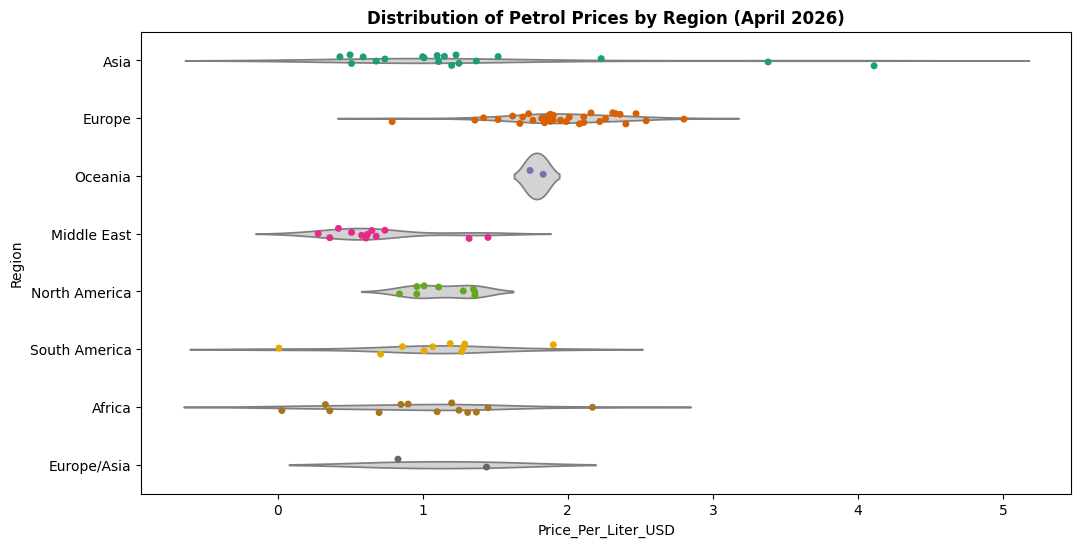

In [13]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Price_Per_Liter_USD', y='Region', color='lightgray', inner=None)
sns.stripplot(data=df, x='Price_Per_Liter_USD', y='Region', size=5, jitter=True, palette='Dark2', hue='Region', legend=False)
plt.title('Distribution of Petrol Prices by Region (April 2026)', fontweight='bold')
plt.show()

**Observation**

Europe consistently maintains the highest baseline prices, with the bulk of its countries clustered at the top end of the scale. Asia exhibits the widest variance it contains both extremely cheap markets and the most expensive outliers globally. Meanwhile, the Middle East and Africa are tightly clustered at the lower end of the pricing spectrum.

## Ranking the Top/Bottom Extremes (Countries)

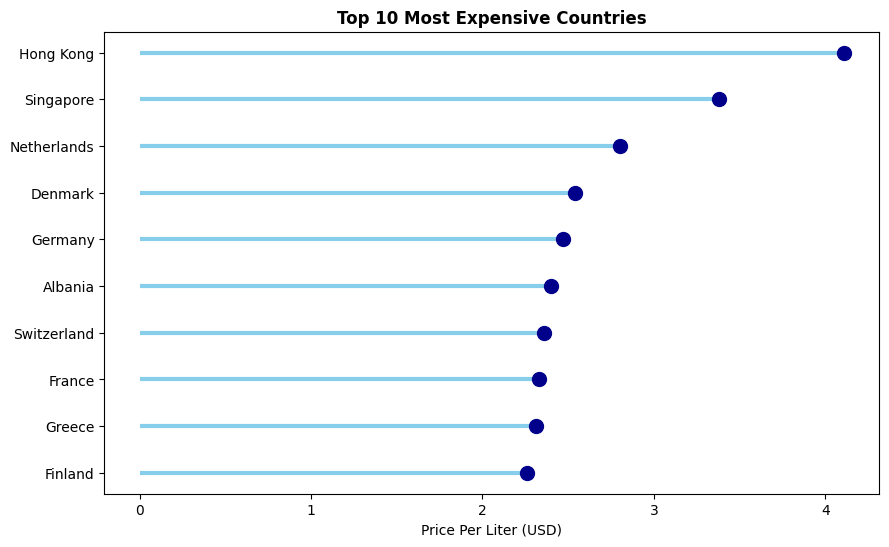

In [14]:
top10 = df.nlargest(10, 'Price_Per_Liter_USD')

plt.figure(figsize=(10, 6))

plt.hlines(y=top10['Country'], xmin=0, xmax=top10['Price_Per_Liter_USD'], color='skyblue', linewidth=3)
plt.plot(top10['Price_Per_Liter_USD'], top10['Country'], "o", markersize=10, color='darkblue')

plt.title('Top 10 Most Expensive Countries', fontweight='bold')
plt.xlabel('Price Per Liter (USD)')

plt.gca().invert_yaxis()

plt.show()

**Observation**

Hong Kong leads the chart by a significant margin as the most expensive place for petrol globally (over $4.00/liter). The rest of the top 10 is heavily dominated by European nations and wealthy Asian city-states like Singapore.

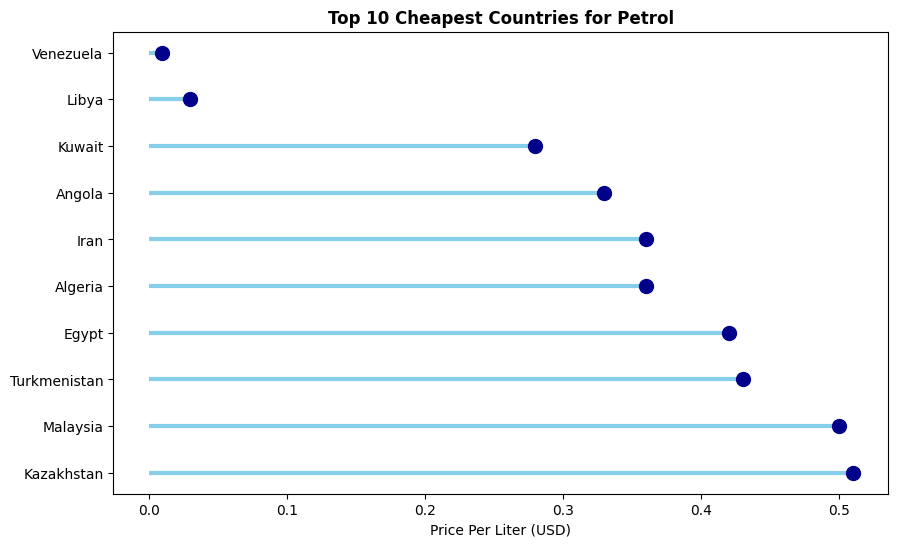

In [15]:
bottom10 = df.nsmallest(10, 'Price_Per_Liter_USD')

plt.figure(figsize=(10, 6))

plt.hlines(y=bottom10['Country'], xmin=0, xmax=bottom10['Price_Per_Liter_USD'], color='skyblue', linewidth=3)
plt.plot(bottom10['Price_Per_Liter_USD'], bottom10['Country'], "o", markersize=10, color='darkblue')

plt.title('Top 10 Cheapest Countries for Petrol', fontweight='bold')
plt.xlabel('Price Per Liter (USD)')

plt.gca().invert_yaxis() 

plt.show()

**observation**

The cheapest petrol markets (nearing $0.01 to $0.10/liter) are almost exclusively major oil-producing nations, largely concentrated in the Middle East and parts of South America. This indicates heavy government subsidies and domestic resource abundance rather than free-market pricing.

## Categorical Breakdown (Trends & Levels)

In [16]:
fig = px.sunburst(df, path=['Region', 'Price_Trend'], values='Price_Per_Liter_USD', 
                  title='Global Petrol Trends by Region')
fig.show(renderer="iframe")

**Observation**

* Looking at the sunburst chart, the global market sentiment heavily leans toward "Rising" or *
"Stable" prices across almost all regions.

* For "Falling" or "Falling Sharply" trends make up a very small sliver of the global market, indicating widespread inflationary pressures on fuel as of April 2026

## Global Geographical Mapping

In [17]:
fig = px.choropleth(df, locations="Country", locationmode='country names',
                    color="Price_Per_Liter_USD", hover_name="Country",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title="Global Petrol Prices Heatmap")
fig.show(renderer="iframe")

**Observation**

The heat map clearly visualizes a global divide in energy costs. Western Europe and Oceania light up as high-cost zones (brighter yellow/plasma colors), while massive landmasses in North America, South America, and Africa remain in the darker, moderate-to-low price tiers.

## Volatility

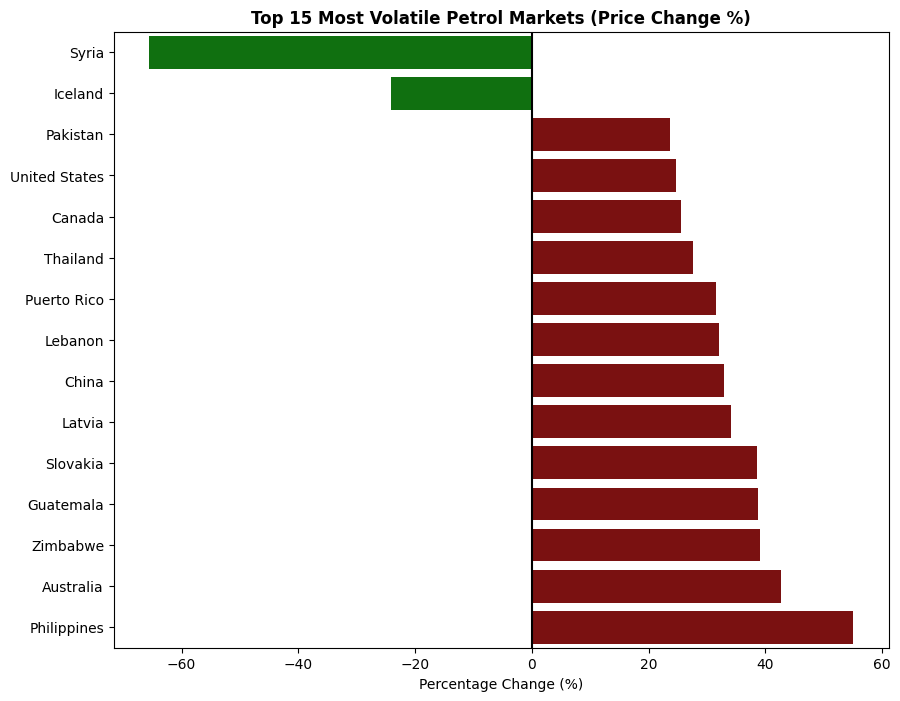

In [18]:
volatile = df.iloc[df['Price_Change_Percent'].abs().argsort()[-15:]].copy()
volatile = volatile.sort_values('Price_Change_Percent')

plt.figure(figsize=(10, 8))

colors = ['green' if x < 0 else 'darkred' for x in volatile['Price_Change_Percent']]

sns.barplot(data=volatile, x='Price_Change_Percent', y='Country', hue='Country', palette=colors, legend=False)
plt.axvline(0, color='black', linewidth=1.5) 

plt.title('Top 15 Most Volatile Petrol Markets (Price Change %)', fontweight='bold')
plt.xlabel('Percentage Change (%)')
plt.ylabel('')
plt.show()

**Observation**

The diverging bar chart highlights extreme localized price shocks. Several countries on the right side of the baseline (like the Philippines, Australia, Zimbabwe, and Guatemala) are experiencing massive percentage increases, pointing to acute regional supply chain issues or sudden economic shifts, rather than just steady global inflation.

# Conclusion & Key Insights

After exploring and visualizing the **Global Petrol Prices (April 2026)** dataset, several clear themes emerge regarding the state of the global energy market:

* **The Geographical Price Divide:** The global petrol market is deeply fragmented. Wealthy Asian hubs (like Hong Kong and Singapore) and European nations consistently bear the highest fuel costs. Conversely, major oil-producing regions (primarily in the Middle East and South America) maintain exceptionally low prices (often under $0.10/liter), pointing heavily to state subsidies rather than free-market pricing.
  
* **Widespread Inflationary Pressure:** The global market sentiment leans heavily toward inflation. With the vast majority of the 101 tracked countries experiencing "Rising" or "Stable" trends, and very few seeing "Falling" prices, it is clear that sustained pressure on global fuel costs remains a dominant economic factor in 2026.
  
* **Localized Extreme Volatility:** While the global average price sits at $1.38 per liter, regional shocks are causing massive price swings. Countries like the Philippines, Australia, and Zimbabwe are experiencing intense, localized price surges that vastly outpace the global average change, indicating acute supply chain or economic crises in those specific markets.

**Final Takeaway:** Petrol pricing in 2026 is less about a single global standard and more about a country's geographical resources, wealth, and local economic stability.